In [1]:
import numpy as np
import scipy.integrate as integrate
import scipy.special as special
import matplotlib.pyplot as plt

# Zadanie 1.

In [3]:
x = np.array([0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50])
F = np.array([0, 37, 71, 104, 134, 161, 185, 207, 225, 239, 250])
L = 0.5
m = 0.075
W = integrate.simpson(y=F, x=x)
v = np.sqrt(2 * W / m)
print(f"Praca (Simpson): {W:.4f} J")
print(f"Predkosc strzaly: {v:.4f} m/s")

Praca (Simpson): 74.5333 J
Predkosc strzaly: 44.5820 m/s


# Zadanie 2.

In [4]:
m2 = 0.8
l2 = 0.4
mu = 0.3
k = 80.0
g = 9.81

def f(x_val):
    return mu * g + (k / m2) * (mu * l2 + x_val) * (1 - l2 / np.sqrt(l2**2 + x_val**2))

W2, _ = integrate.quad(f, 0, l2)
v0 = np.sqrt(2 * W2)
print(f"Czesci (a) - v0: {v0:.4f} m/s")

def integrand(z):
    return 1.0 / np.sqrt((np.sqrt(2) - 1)**2 - (np.sqrt(1 + z) - 1)**2)

C, _ = integrate.quad(integrand, 0, 1)
t = C * np.sqrt(m2 / k)
print(f"Czesc (b) - Stala C: {C:.6f}")
print(f"Czesc (b) - Czas t: {t:.6f} s")

Czesci (a) - v0: 2.4977 m/s
Czesc (b) - Stala C: 3.970020
Czesc (b) - Czas t: 0.397002 s


# Zadanie 3.

Zadanie 3 (Kwadratury) - Calka K(k): 1.6336
Zadanie 3 (Kwadratury) - Okres T: 2.0863 s\n
Zadanie 3 (AGM) - Calka K(k): 1.6336
Zadanie 3 (AGM) - Okres T: 2.0863 s


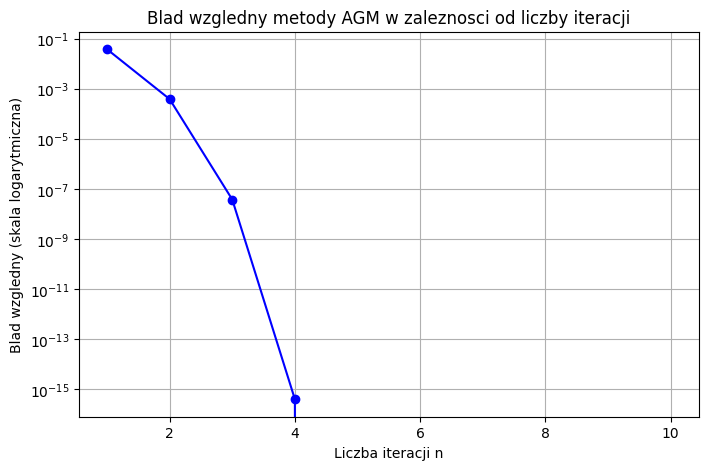

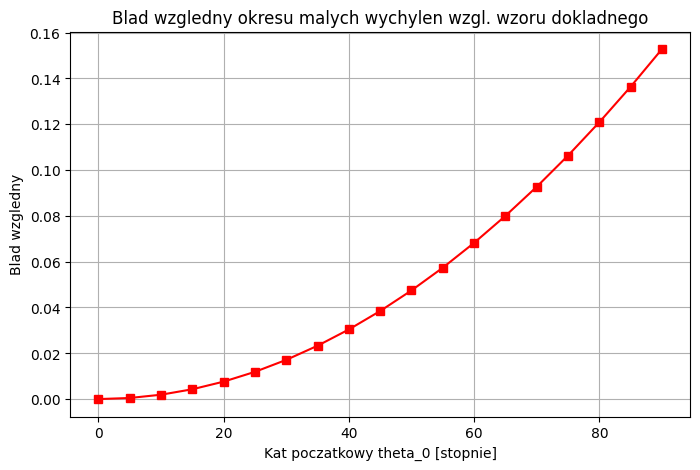

In [ ]:
l3 = 1.0
theta0 = np.pi / 4
k_val = np.sin(theta0 / 2)

def K_integrand(theta):
    return 1.0 / np.sqrt(1 - k_val**2 * np.sin(theta)**2)

K_quad, _ = integrate.quad(K_integrand, 0, np.pi / 2)
T_quad = 4 * np.sqrt(l3 / g) * K_quad
print(f"Zadanie 3 (Kwadratury) - Calka K(k): {K_quad:.4f}")
print(f"Zadanie 3 (Kwadratury) - Okres T: {T_quad:.4f} s\\n")

def agm(a, b, n_iters):
    a_vals = [a]
    b_vals = [b]
    for _ in range(n_iters):
        a_next = (a_vals[-1] + b_vals[-1]) / 2.0
        b_next = np.sqrt(a_vals[-1] * b_vals[-1])
        a_vals.append(a_next)
        b_vals.append(b_next)
    return a_vals, b_vals

max_iters = 10
a_seq, b_seq = agm(1 + k_val, 1 - k_val, max_iters)
K_agm_vals = [(np.pi / 2) / a for a in a_seq[1:]]
K_exact = special.ellipk(k_val**2)
errors_agm = np.abs(np.array(K_agm_vals) - K_exact) / K_exact

K_agm_final = K_agm_vals[-1]
T_agm_final = 4 * np.sqrt(l3 / g) * K_agm_final
print(f"Zadanie 3 (AGM) - Calka K(k): {K_agm_final:.4f}")
print(f"Zadanie 3 (AGM) - Okres T: {T_agm_final:.4f} s")

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_iters + 1), errors_agm, marker='o', linestyle='-', color='b')
plt.yscale('log')
plt.title('Blad wzgledny metody AGM w zaleznosci od liczby iteracji')
plt.xlabel('Liczba iteracji n')
plt.ylabel('Blad wzgledny (skala logarytmiczna)')
plt.grid(True)
plt.show()

thetas = np.arange(0, 95, 5) * np.pi / 180
T_exact_vals = []
T_approx_vals = []

for th in thetas:
    if th == 0:
        T_exact_vals.append(2 * np.pi * np.sqrt(l3 / g))
    else:
        k_th = np.sin(th / 2)
        K_th = special.ellipk(k_th**2)
        T_exact_vals.append(4 * np.sqrt(l3 / g) * K_th)
    T_approx_vals.append(2 * np.pi * np.sqrt(l3 / g))

T_exact_vals = np.array(T_exact_vals)
T_approx_vals = np.array(T_approx_vals)
errors_T = np.abs(T_approx_vals - T_exact_vals) / T_exact_vals
errors_T[0] = 0.0

plt.figure(figsize=(8, 5))
plt.plot(thetas * 180 / np.pi, errors_T, marker='s', linestyle='-', color='r')
plt.title('Blad wzgledny okresu malych wychylen wzgl. wzoru dokladnego')
plt.xlabel('Kat poczatkowy theta_0 [stopnie]')
plt.ylabel('Blad wzgledny')
plt.grid(True)
plt.show()